In [11]:
import mne
import re


# Load

Load bci, fix channels naming and assign montage

In [14]:
VALID_1020 = [
    # Frontal / Prefrontal
    'Fp1','Fpz','Fp2','AF7','AF3','AFz','AF4','AF8',
    'F7','F5','F3','F1','Fz','F2','F4','F6','F8',
    # Frontocentral / Central
    'FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8',
    'T7','C5','C3','C1','Cz','C2','C4','C6','T8',
    # Temporo-parietal / Parietal
    'T9','TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8','T10',
    'P7','P5','P3','P1','Pz','P2','P4','P6','P8',
    # Parieto-occipital / Occipital
    'PO7','PO3','POz','PO4','PO8','O1','Oz','O2','Iz'
]

CANON = {name.lower(): name for name in VALID_1020}

def normalize_ch_name(name: str) -> str:
    base = re.sub(r"\.", "", name)
    key  = base.lower()
    return CANON.get(key, base)

def normalize_and_set_montage(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    mapping = {old: normalize_ch_name(old) for old in raw.ch_names}

    raw.rename_channels(mapping)

    ch_types = {}
    for ch in raw.ch_names:
        low = ch.lower()
        if 'sti' in low:
            ch_types[ch] = 'stim'
        elif low.startswith('eog') or low in ('eogl','eogr','veog','heog'):
            ch_types[ch] = 'eog'
    if ch_types:
        raw.set_channel_types(ch_types)

    raw.set_montage('standard_1020')

    return raw



def load_bci(subject=1, runs=[6, 10]):
    rawfiles = mne.datasets.eegbci.load_data(subject, runs)

    raw_l = mne.io.read_raw_edf(rawfiles[0], preload=True)
    raw_r = mne.io.read_raw_edf(rawfiles[1], preload=True)

    raw_l = normalize_and_set_montage(raw_l)
    raw_r = normalize_and_set_montage(raw_r)

    return raw_l, raw_r

In [40]:
raw_l, raw_r = load_bci()

Extracting EDF parameters from /home/may33/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /home/may33/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [42]:
raw = raw_l

wraw= raw.copy()

In [43]:
wraw.plot()

Channels marked as bad:
none


# Signal processing

## Compute Spectral Analysis to see which frequencies occurs

In [44]:
wraw = wraw.filter(8, 30);

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



In [27]:
psd = raw_l.compute_psd()

Effective window size : 12.800 (s)


Plotting power spectral density (dB=True).


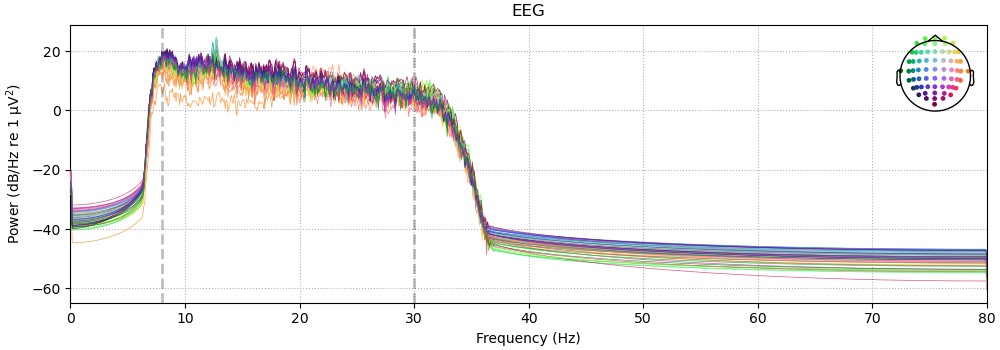

In [45]:
%matplotlib widget

psd.plot(show=False);

In [46]:
wraw.set_eeg_reference(ref_channels='average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [47]:
wraw.plot();

Channels marked as bad:
none


In [48]:
ica_raw = raw.copy()

In [50]:
ica_raw.filter(l_freq = 1, h_freq = None)
ica_raw.notch_filter(60)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 529 samples (3.306 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples

<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [51]:
from mne.preprocessing import ICA

ica = ICA(
    n_components=63,
    method='fastica',
    random_state=97,
    max_iter='auto'
)

In [52]:
ica.fit(ica_raw, decim=3)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 63 components
Fitting ICA took 1.4s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,404 iterations on raw data (6667 samples)
ICA components,63
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


In [ ]:
ica.plot_components(show=False);

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated


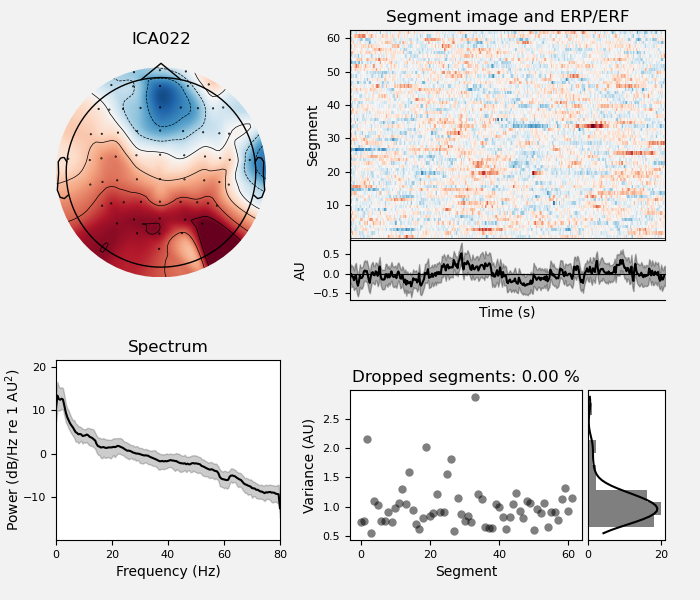

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

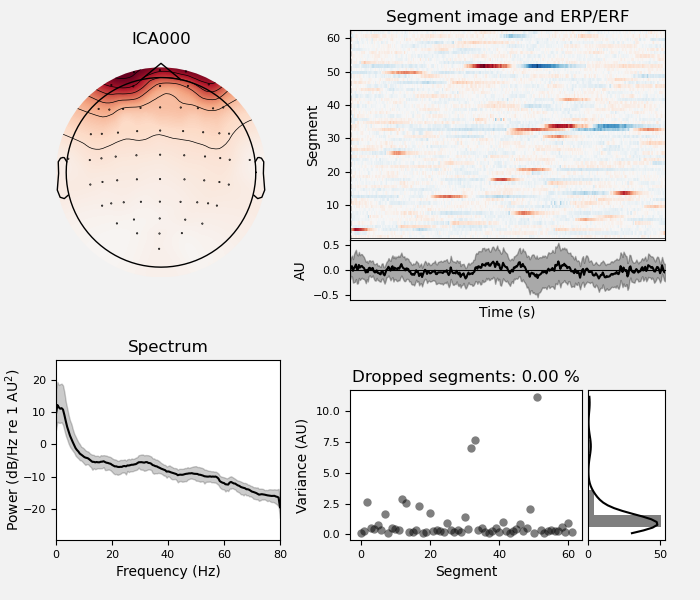

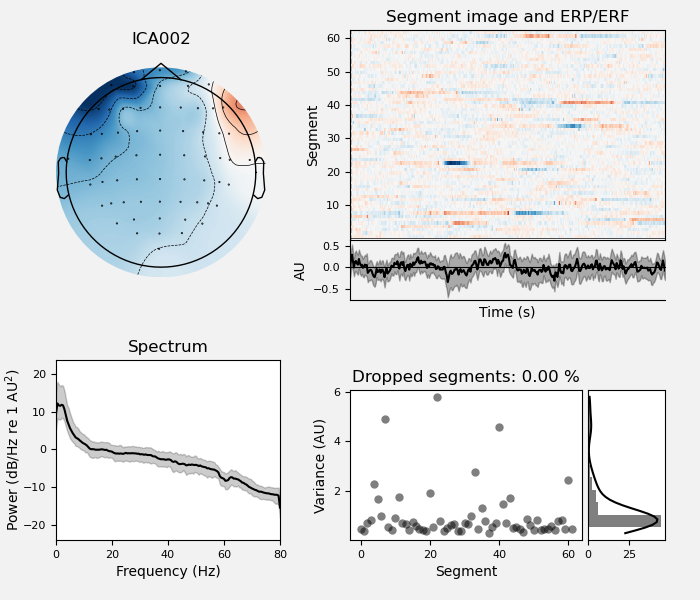

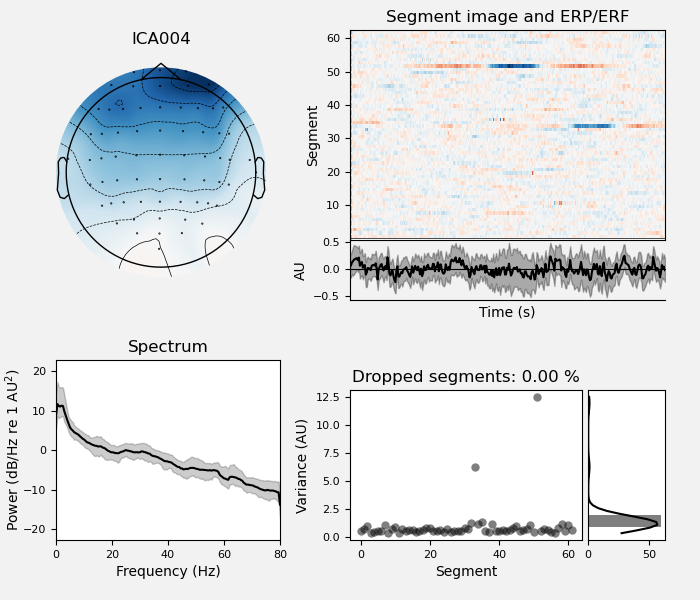

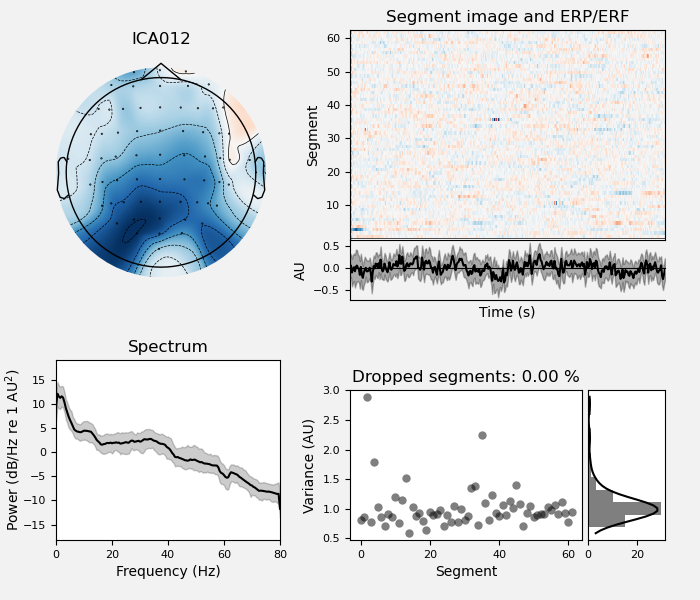

In [ ]:
ica.plot_properties(ica_raw, picks=[0, 1,2,3,4, 5])  # временной ряд/PSD IC

In [60]:
eog_find = []
for ch in ['Fpz','Fp1','Fp2']:
    idx, scores = ica.find_bads_eog(ica_raw, ch)
    eog_find.append((idx, scores))

Using EOG channel: Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- 

In [61]:
for ch in eog_find:
    print(ch[0])

[np.int64(0), np.int64(4), np.int64(2)]
[np.int64(0), np.int64(2), np.int64(4)]
[np.int64(0), np.int64(4)]


In [64]:
ica.exclude = [0,2,4]

In [65]:
wraw_ica = ica.apply(wraw.copy())

Applying ICA to Raw instance
    Transforming to ICA space (63 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components


Applying ICA to Raw instance
    Transforming to ICA space (63 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components


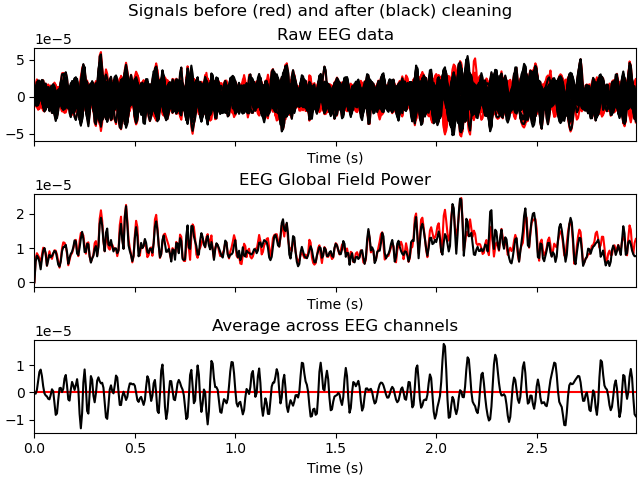

In [68]:
ica.plot_overlay(wraw, exclude=[0, 2, 4], show=False);

In [69]:
wraw_ica.plot()

Using EOG channel: Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- 

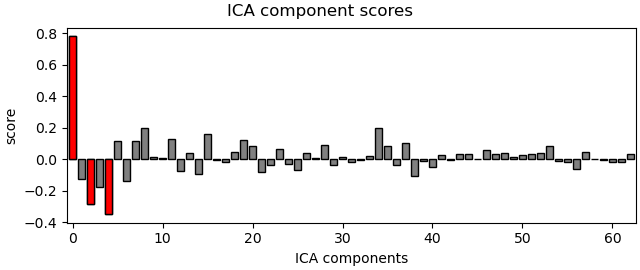

In [76]:
inds, scores = ica.find_bads_eog(ica_raw, ch_name='Fpz')  # и Fp1/Fp2
ica.plot_scores(scores, show=False);